In [1]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers.models.bert.modeling_bert import BertPreTrainedModel, BertModel
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as Fun
import transformers
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore') # setting ignore as a parameter

c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# get predict result
def get_pred(logits):
    # logits shape: (batch_size, num_classes)
    # 使用 argmax 選出每一筆的最大值位置 (代表預測的class)
    preds = torch.argmax(logits, dim=1)
    return preds

# calculate confusion metrics
def cal_metrics(pred, ans):
    # 把 tensor 轉成 numpy array
    pred = pred.cpu().numpy()
    ans = ans.cpu().numpy()

    acc = accuracy_score(ans, pred)
    f1 = f1_score(ans, pred, average='macro')  # 多類別情緒建議用 macro
    recall = recall_score(ans, pred, average='macro')
    precision = precision_score(ans, pred, average='macro')

    return acc, f1, recall, precision

# save model to path
def save_checkpoint(save_path, model):
  if save_path == None:
      return
  torch.save(model.state_dict(), save_path)
  print(f'Model saved to ==> {save_path}')

# load model from path
def load_checkpoint(load_path, model, device):
  if load_path==None:
      return
  state_dict = torch.load(load_path, map_location=device)
  print(f'Model loaded from <== {load_path}')

  model.load_state_dict(state_dict)
  return model

### 數據預處理

In [3]:
import re

# 文字預處理：小寫化 + 移除多餘符號
def clean_text(text):
    text = text.strip().lower()  # 去前後空白 + 全部小寫
    
    text = re.sub(r"<br\s*/?>", " ", text)  # 處理HTML的<br>標籤
    text = re.sub(r"[^a-z0-9\s.,!?']", "", text)  # 刪除非法字元
    text = re.sub(r"([.!?,])\1{1,}", r"\1", text)  # 壓縮連續標點
    text = re.sub(r"\s+", " ", text)  # 壓縮空白

    # 把連續空格壓成一個空格
    text = re.sub(r"\s+", " ", text)

    return text

## 載入資料

這個資料集有分成train, test, unsupervised。

這次我們只使用train及test資料，且我們需要將原資料重新進行分割。

將兩份資料合併後切割成 3:1:1 或是 8:1:1 的 train/val/test 資料集。

In [4]:
from datasets import load_dataset
dataset = load_dataset("imdb")

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 先取出資料
train_data = dataset['train']
test_data = dataset['test']

# 把 train 和 test 合併
all_data = pd.DataFrame({
    'text': train_data['text'] + test_data['text'],
    'label': train_data['label'] + test_data['label']
})

# 重新切割成新的 train/test (例如 80% train, 20% test)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    all_data['text'], 
    all_data['label'], 
    test_size=0.2, 
    random_state=42,
    stratify=all_data['label'] # 保持分類比例一樣
)

# 把切好的資料整理成 DataFrame
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
test_df = pd.DataFrame({'text': test_texts, 'label': test_labels})

# --- 新增計算平均字串長度 ---
train_lengths = train_df['text'].apply(lambda x: len(x))
test_lengths = test_df['text'].apply(lambda x: len(x))

# 計算每一筆資料的字數（以空格分隔）
train_word_counts = train_df['text'].apply(lambda x: len(x.split()))
test_word_counts = test_df['text'].apply(lambda x: len(x.split()))

print(f"New train size: {len(train_df)}, New test size: {len(test_df)}")
print(f"Train set 平均字串長度: {train_lengths.mean():.2f} 字元")
print(f"Test set 平均字串長度: {test_lengths.mean():.2f} 字元")
print(f"Train set 平均字數: {train_word_counts.mean():.2f} 字")
print(f"Test set 平均字數: {test_word_counts.mean():.2f} 字")
train_df.head()


New train size: 40000, New test size: 10000
Train set 平均字串長度: 1308.34 字元
Test set 平均字串長度: 1313.79 字元
Train set 平均字數: 230.94 字
Test set 平均字數: 232.02 字


,text,label
48903,Having a close experience with one such patien...,1
10174,This is by far one of the worst movies i have ...,0
34019,This film is a great disappointment. Director ...,0
9815,"When I first popped in Happy Birthday to Me, I...",0
6895,I signed in just to comment on how awfully stu...,0


In [7]:
all_data['label'].value_counts() / len(all_data)

label
0    0.5
1    0.5
Name: count, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_data = train_test_split(all_data, random_state=1111, train_size=0.8)
dev_df, test_df = train_test_split(temp_data, random_state=1111, train_size=0.5)
print('# of train_df:', len(train_df))
print('# of dev_df:', len(dev_df))
print('# of test_df data:', len(test_df))

# save data
train_df.to_csv('./train.tsv', sep='\t', index=False)
dev_df.to_csv('./val.tsv', sep='\t', index=False)
test_df.to_csv('./test.tsv', sep='\t', index=False)

# of train_df: 40000
# of dev_df: 5000
# of test_df data: 5000


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import torch
import torch.nn.functional as Fun

# Using Dataset to build DataLoader
class CustomDataset(Dataset):
    def __init__(self, mode, df, specify, args):
        assert mode in ["train", "val", "test"]  # 一般會切三份
        self.mode = mode
        self.df = df
        self.specify = specify # specify column of data (the column U use for predict)
        if self.mode != 'test':
            self.label = df['label']
        self.tokenizer = AutoTokenizer.from_pretrained(args["config"])
        self.max_len = args["max_len"]
        self.num_class = args["num_class"]

    def __len__(self):
        return len(self.df)

    # transform label to one_hot label (if num_class > 2)
    def one_hot_label(self, label):
        return Fun.one_hot(torch.tensor(label), num_classes = self.num_class)

    # transform text to its number
    def tokenize(self, input_text):
        # 小寫化
        input_text = clean_text(input_text)

        # 使用 tokenizer 處理文字，注意要 padding 和 truncation
        tokens = self.tokenizer(
            input_text,
            padding='max_length',         # 補到 max_len
            truncation=True,              # 超過的話截斷
            max_length=self.max_len,
            return_tensors='pt'            # 回傳 pytorch tensor
        )
    
        # squeeze 把 batch 維度去掉 (因為目前是單一樣本)
        input_ids = tokens['input_ids'].squeeze(0)
        attention_mask = tokens['attention_mask'].squeeze(0)
        token_type_ids = tokens['token_type_ids'].squeeze(0)

        return input_ids, attention_mask, token_type_ids


    # get single data
    def __getitem__(self, index):

        sentence = str(self.df[self.specify][index])
        ids, mask, token_type_ids = self.tokenize(sentence)


        if self.mode == "test":
            return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.long), \
                torch.tensor(token_type_ids, dtype=torch.long)
        else:
            if self.num_class > 2:
                return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.long), \
                    torch.tensor(token_type_ids, dtype=torch.long), self.one_hot_label(self.label[index])
            else:
                return torch.tensor(ids, dtype=torch.long), torch.tensor(mask, dtype=torch.long), \
                    torch.tensor(token_type_ids, dtype=torch.long), torch.tensor(self.label[index], dtype=torch.long)

## 建立模型
在初始化的地方加上dropout, linear layer（等於一層NN），其維度為類別數量

在forward function中把輸入值放進對應層數（bert -> dropout -> classifier）； 請注意我們只取用bert輸出的sentence representation去做分類

In [10]:
import torch.nn as nn

# BERT Model
class BertClassifier(BertPreTrainedModel):
    def __init__(self, config, args):
        super(BertClassifier, self).__init__(config)
        self.bert = BertModel(config)

        # 新增 Dropout 和 Linear layer
        self.dropout = nn.Dropout(args["dropout"])  # 加入參數控制 dropout
        self.classifier = nn.Linear(config.hidden_size, args["num_class"])  # hidden_size -> 類別數量

        self.init_weights()

    # forward function, data in model will do this
    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, position_ids=None,
                head_mask=None, inputs_embeds=None, labels=None, output_attentions=None,
                output_hidden_states=None, return_dict=None):
        
        # BERT encoder
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
            head_mask=head_mask,
            inputs_embeds=inputs_embeds,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict
        )

        # outputs[0] = last_hidden_state, outputs[1] = pooler_output
        # 這邊取 pooler_output，代表 [CLS] token 的向量
        pooled_output = outputs[1]

        # Dropout -> Classifier
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits

In [11]:
from tqdm import tqdm

# evaluate dataloader
def evaluate(model, data_loader, device):
    val_loss, val_acc, val_f1, val_rec, val_prec = 0.0, 0.0, 0.0, 0.0, 0.0
    step_count = 0
    loss_fct = torch.nn.CrossEntropyLoss()
    model.eval()

    with torch.no_grad():
        for data in tqdm(data_loader, desc="Evaluating", leave=False):
            ids, masks, token_type_ids, labels = [t.to(device) for t in data]

            logits = model(
                input_ids=ids,
                token_type_ids=token_type_ids,
                attention_mask=masks
            )

            acc, f1, rec, prec = cal_metrics(get_pred(logits), labels)
            loss = loss_fct(logits, labels)

            val_loss += loss.item()
            val_acc += acc
            val_f1 += f1
            val_rec += rec
            val_prec += prec
            step_count += 1

    val_loss = val_loss / step_count
    val_acc = val_acc / step_count
    val_f1 = val_f1 / step_count
    val_rec = val_rec / step_count
    val_prec = val_prec / step_count

    return val_loss, val_acc, val_f1, val_rec, val_prec

In [12]:
from datetime import datetime
parameters = {
    "num_class": 2,
    "time": str(datetime.now()).replace(" ", "_"),
    "model_name": 'BERT',
    "config": 'bert-base-uncased',
    "learning_rate": 4e-5,        # 小一點
    "epochs": 4,                  # 初步 3 次，感覺好再加
    "max_len": 512,               # 訓練速度快很多且夠用
    "batch_size": 128,
    "dropout": 0.1                # 先小，視overfit狀況調整
}

In [13]:
import multiprocessing

def get_optimal_num_workers():
    cpu_count = multiprocessing.cpu_count()  # 獲取CPU邏輯核心數
    if cpu_count <= 4:
        return 2
    elif cpu_count <= 8:
        return 4
    elif cpu_count <= 16:
        return 8
    else:
        return 12  # 24核以上，給12 workers很安全穩定

### 載入資料

讀入資料並傳入自訂的Dataset以自訂資料格式

之後傳入DataLoader以利後續訓練進行（將資料批次化以免記憶體爆掉）

(# 你可以決定要sample部分資料還是全部都丟進去)

In [14]:
import transformers
import pandas as pd

optimal_workers = get_optimal_num_workers()

# load training data
train_df = pd.read_csv('./train.tsv', sep = '\t').sample(4000).reset_index(drop=True)
train_dataset = CustomDataset('train', train_df, 'text', parameters)
train_loader = DataLoader(train_dataset, batch_size=parameters['batch_size'], shuffle=True, pin_memory=True)

# load training data
# train_df = pd.read_csv('./train.tsv', sep='\t').reset_index(drop=True)  # << 全部資料
# train_dataset = CustomDataset('train', train_df, 'text', parameters)
# train_loader = DataLoader(train_dataset, batch_size=parameters['batch_size'], shuffle=True, num_workers=optimal_workers, pin_memory=False)  # 建議加num_workers

# load validation data
val_df = pd.read_csv('./val.tsv', sep = '\t').sample(500).reset_index(drop=True)
val_dataset = CustomDataset('val', val_df, 'text', parameters)
val_loader = DataLoader(val_dataset, batch_size=parameters['batch_size'], shuffle=True, pin_memory=True)

### 初始化模型
*   載入模型（這邊會使用已經訓練過的模型，Fine-tune我們的資料集）
*   定義Optimization
  *   通常用Adam就可以了，你也可以換SGD之類的試看看
  *   可以自己看需不需要加scheduler（可以自己寫一個function，也可以直接套用現有的function）
  
  ［請記得pytorch中是以step去計算，想要用epoch去訂定需自行換算］

In [15]:
from transformers import get_cosine_schedule_with_warmup, get_linear_schedule_with_warmup

transformers.logging.set_verbosity_error() # close the warning message

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertClassifier.from_pretrained(parameters['config'], parameters).to(device)
loss_fct = torch.nn.CrossEntropyLoss() # we use cross entrophy loss

## You can custom your optimizer (e.g. SGD .etc) ##
# we use Adam here
optimizer = torch.optim.Adam(model.parameters(), lr=parameters['learning_rate'], betas=(0.9, 0.999), eps=1e-9)

def get_scheduler(scheduler_type, optimizer, num_warmup_steps, num_training_steps):
    """
    根據 scheduler_type 自動建立 scheduler

    Args:
        scheduler_type (str): 選擇 'cosine' 或 'linear'
        optimizer (torch.optim.Optimizer): 你的optimizer
        num_warmup_steps (int): warmup步數
        num_training_steps (int): 總訓練步數

    Returns:
        scheduler (torch.optim.lr_scheduler._LRScheduler)
    """
    if scheduler_type == 'cosine':
        return get_cosine_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=num_warmup_steps, 
            num_training_steps=num_training_steps,
            num_cycles=1
        )
    elif scheduler_type == 'linear':
        return get_linear_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=num_warmup_steps, 
            num_training_steps=num_training_steps
        )
    else:
        raise ValueError(f'Unknown scheduler type: {scheduler_type}')

* 因為是做分類任務，所以這裡用CrossEntrophyLoss
* 由於在pytorch中，CrossEntrophyLoss吃的input是未經softmax的值，所以在模型中不必加入softmax
* 但若在後期想取得各類別實際機率就要經過softmax轉換
* logits的數值不等於機率 ！！但一般而言，logits中較大者會與經過softmax轉換後的結果一致

In [16]:
from tqdm import tqdm
import time

metrics = ['loss', 'acc', 'f1', 'rec', 'prec']
mode = ['train_', 'val_']
record = {s+m : [] for s in mode for m in metrics}

# Early stopping設定
early_stop_patience = 3  # 如果連續3個epoch沒進步就停
best_val_loss = float('inf')  # 目前觀察到最好的驗證損失
patience_counter = 0  # 沒進步的次數

# 先定義scheduler
num_train_steps = len(train_loader) * parameters['epochs']
num_warmup_steps = int(0.1 * num_train_steps)  # 10% warmup
scheduler_type = 'cosine'  # 選 'cosine' 或 'linear'
scheduler = get_scheduler(scheduler_type, optimizer, num_warmup_steps, num_train_steps)


for epoch in range(parameters["epochs"]):

    st_time = time.time()
    train_loss, train_acc, train_f1, train_rec, train_prec = 0.0, 0.0, 0.0, 0.0, 0.0
    step_count = 0

    model.train()  # 開啟訓練模式

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=True)
    
    for batch in train_loader_tqdm:
        input_ids, attention_mask, token_type_ids, labels = [x.to(device) for x in batch]

        # 前向傳播
        logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

        # 計算損失
        loss = loss_fct(logits, labels)

        # 反向傳播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        # 記錄 loss
        train_loss += loss.item()

        # 預測
        preds = get_pred(logits)

        # 計算指標
        acc, f1, rec, prec = cal_metrics(preds, labels)
        train_acc += acc
        train_f1 += f1
        train_rec += rec
        train_prec += prec

        step_count += 1

        # --- 更新進度條顯示 ---
        avg_loss = train_loss / step_count
        avg_acc = train_acc / step_count
        train_loader_tqdm.set_postfix(loss=avg_loss, acc=avg_acc)

    # --- Evaluate after epoch ---
    val_loss, val_acc, val_f1, val_rec, val_prec = evaluate(model, val_loader, device)

    train_loss = train_loss / step_count
    train_acc = train_acc / step_count
    train_f1 = train_f1 / step_count
    train_rec = train_rec / step_count
    train_prec = train_prec / step_count

    print(f'\n[Epoch {epoch+1}] Time: {time.time() - st_time:.2f}s')
    print('         loss     acc     f1      rec    prec')
    print('train | %.4f, %.4f, %.4f, %.4f, %.4f' % (train_loss, train_acc, train_f1, train_rec, train_prec))
    print('val   | %.4f, %.4f, %.4f, %.4f, %.4f\n' % (val_loss, val_acc, val_f1, val_rec, val_prec))

    # record training metrics of each training epoch
    record['train_loss'].append(train_loss)
    record['train_acc'].append(train_acc)
    record['train_f1'].append(train_f1)
    record['train_rec'].append(train_rec)
    record['train_prec'].append(train_prec)

    record['val_loss'].append(val_loss)
    record['val_acc'].append(val_acc)
    record['val_f1'].append(val_f1)
    record['val_rec'].append(val_rec)
    record['val_prec'].append(val_prec)

    # --- EarlyStopping檢查 ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0  # 有進步，reset counter
        save_checkpoint(f"best_model_epoch{epoch+1}.pt", model)  # 保存最佳模型
    else:
        patience_counter += 1
        print(f"No improvement in val_loss for {patience_counter} epochs.")

    if patience_counter >= early_stop_patience:
        print("Early stopping triggered!")
        break

Epoch 1 - Training: 100%|██████████| 32/32 [1:51:00<00:00, 208.14s/it, acc=0.746, loss=0.5]  



[Epoch 1] Time: 6712.33s
         loss     acc     f1      rec    prec
train | 0.4996, 0.7456, 0.7319, 0.7458, 0.7563
val   | 0.3681, 0.8467, 0.8441, 0.8485, 0.8688

Model saved to ==> best_model_epoch1.pt


Epoch 2 - Training: 100%|██████████| 32/32 [1:55:10<00:00, 215.96s/it, acc=0.915, loss=0.222]



[Epoch 2] Time: 6963.27s
         loss     acc     f1      rec    prec
train | 0.2218, 0.9148, 0.9140, 0.9154, 0.9182
val   | 0.2455, 0.9017, 0.9015, 0.9014, 0.9019

Model saved to ==> best_model_epoch2.pt


Epoch 3 - Training: 100%|██████████| 32/32 [1:57:04<00:00, 219.51s/it, acc=0.943, loss=0.164] 



[Epoch 3] Time: 7076.77s
         loss     acc     f1      rec    prec
train | 0.1638, 0.9426, 0.9423, 0.9428, 0.9429
val   | 0.2475, 0.9030, 0.9025, 0.9020, 0.9049

No improvement in val_loss for 1 epochs.


Epoch 4 - Training: 100%|██████████| 32/32 [1:57:34<00:00, 220.44s/it, acc=0.954, loss=0.137]  



[Epoch 4] Time: 7106.47s
         loss     acc     f1      rec    prec
train | 0.1366, 0.9543, 0.9539, 0.9545, 0.9544
val   | 0.2316, 0.9114, 0.9109, 0.9115, 0.9114

Model saved to ==> best_model_epoch4.pt


In [17]:
# save model
save_checkpoint('./bert.pt' , model)

Model saved to ==> ./bert.pt


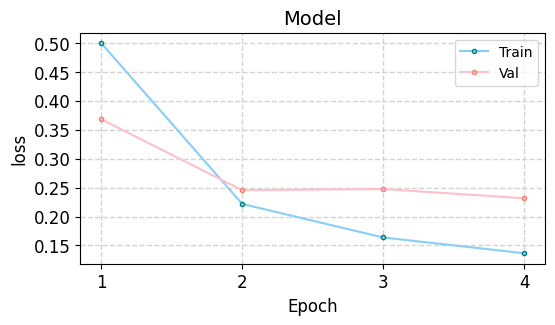

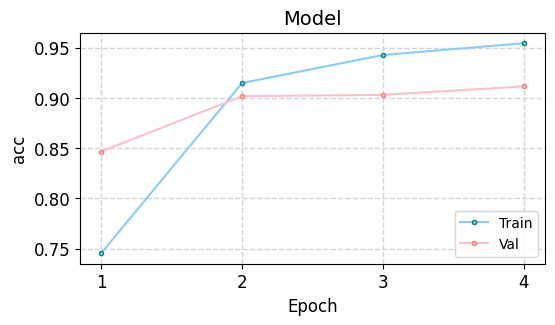

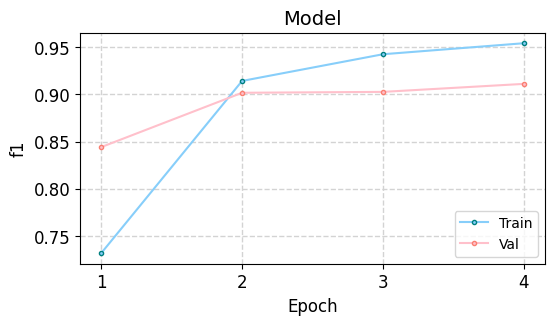

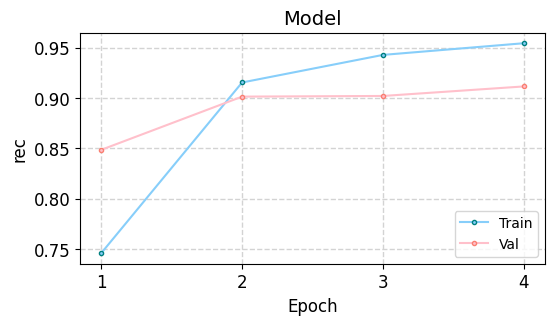

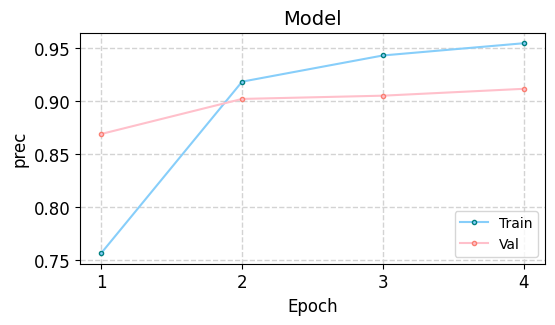

In [18]:
# draw learning curve
import matplotlib.pyplot as plt
def draw_pics(record, name, img_save=False, show=False):
    x_ticks = range(1, parameters["epochs"]+1)

    plt.figure(figsize=(6, 3))

    plt.plot(x_ticks, record['train_'+name], '-o', color='lightskyblue',
             markeredgecolor="teal", markersize=3, markeredgewidth=1, label = 'Train')
    plt.plot(x_ticks, record['val_'+name], '-o', color='pink',
             markeredgecolor="salmon", markersize=3, markeredgewidth=1, label = 'Val')
    plt.grid(color='lightgray', linestyle='--', linewidth=1)

    plt.title('Model', fontsize=14)
    plt.ylabel(name, fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.xticks(x_ticks, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(loc='lower right' if not name.lower().endswith('loss') else 'upper right')

    if img_save:
        plt.savefig(name+'.png', transparent=False, dpi=300)
    if show:
        plt.show()

    plt.close()

draw_pics(record, 'loss', img_save=False, show=True)
draw_pics(record, 'acc', img_save=False, show=True)
draw_pics(record, 'f1', img_save=False, show=True)
draw_pics(record, 'rec', img_save=False, show=True)
draw_pics(record, 'prec', img_save=False, show=True)

In [19]:
def Softmax(x):
  return torch.exp(x) / torch.exp(x).sum()
# label to class
def label2class(label):
  l2c = {0:'negative', 1:'positive'}
  return l2c[label]

In [20]:
def predict_one(query, model):
    model.eval()  # 切成評估模式
    tokenizer = AutoTokenizer.from_pretrained(parameters["config"])  # 用你的 config 初始化tokenizer

    # Tokenize輸入句子
    inputs = tokenizer(
        query,
        padding='max_length',
        truncation=True,
        max_length=parameters["max_len"],
        return_tensors="pt"  # 回傳PyTorch tensor
    )

    # 放到正確的device上 (cpu or cuda)
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)

    with torch.no_grad():
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

    # logits轉成機率
    probs = Softmax(logits.squeeze())  # logits.squeeze()拿掉batch維度

    # 找出最大機率對應的class
    pred_label = torch.argmax(probs).item()
    pred = label2class(pred_label)

    return probs, pred

In [21]:
# you can load model from existing result
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
init_model = BertClassifier.from_pretrained(parameters['config'], parameters) # build an initial model
model = load_checkpoint('./bert.pt', init_model, device).to(device) # and load the weight of model from specify file

Model loaded from <== ./bert.pt


In [22]:
%%time
probs, pred = predict_one("This movie doesn't attract me", model)
print(pred) 

negative
CPU times: total: 1.67 s
Wall time: 551 ms


In [23]:
# predict dataloader
def predict(data_loader, model):

  tokenizer = AutoTokenizer.from_pretrained(parameters['config'])
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  total_probs, total_pred = [], []
  model.eval()
  with torch.no_grad():
    for data in data_loader:
      input_ids, attention_mask, \
      token_type_ids = [t.to(device) for t in data]

      # forward pass
      logits = model(input_ids, attention_mask, token_type_ids)
      probs = Softmax(logits) # get each class-probs
      label_index = torch.argmax(probs[0], dim=0)
      pred = label_index.item()

      total_probs.append(probs)
      total_pred.append(pred)

  return total_probs, total_pred

In [24]:
# load testing data
test_df = pd.read_csv('./test.tsv', sep = '\t').sample(500).reset_index(drop=True)
test_dataset = CustomDataset('test', test_df, 'text', parameters)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

total_probs, total_pred = predict(test_loader, model)
res = test_df.copy()
# add predict class of origin file
res['pred'] = total_pred

# save result
res.to_csv('./result.tsv', sep='\t', index=False)

In [25]:
res.head(5)

,text,label,pred
0,"I liked most of the dialogue, I liked the cast...",0,0
1,A fine line up of actors and a seemingly nice ...,0,0
2,New Year's Day. The day after consuming a few ...,0,0
3,"Idea is great, spoiled big time by the judges....",0,0
4,"Based upon the recommendation of a friend, my ...",0,0


In [26]:
correct = 0
for idx, pred in enumerate(res['pred']):
  if pred == res['label'][idx]:
    correct += 1
print('test accuracy = %.4f'%(correct/len(test_df)))

test accuracy = 0.9180
